# Chapter 5 — Classification

## Learning Objectives

This notebook covers Naive Bayes, logistic regression, confusion matrices, accuracy, precision, recall, specificity, ROC curves, AUC, lift, imbalanced data, and cost-based classification.

## Theoretical Explanation

Classification predicts categorical outcomes. Logistic regression models the log odds of a binary outcome and converts them to probabilities. Naive Bayes uses conditional probabilities with a simplifying independence assumption. Model evaluation is especially important because accuracy can be misleading when classes are imbalanced.

For rare-class problems, precision, recall, specificity, ROC-AUC, and lift are more informative than accuracy alone. The correct metric depends on the cost of false positives and false negatives. In fraud, medicine, and risk scoring, the rare class may be the most important class.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Logistic Regression and Confusion Matrix

In [2]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X, y = make_classification(n_samples=1200, n_features=8, n_informative=4, weights=[0.85, 0.15], random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=RANDOM_STATE)
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)
proba = logreg.predict_proba(X_test)[:,1]
print('Confusion matrix:\n', confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, zero_division=0))
print('ROC-AUC:', round(roc_auc_score(y_test, proba), 4))

Confusion matrix:
 [[249   5]
 [ 30  16]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       254
           1       0.76      0.35      0.48        46

    accuracy                           0.88       300
   macro avg       0.83      0.66      0.71       300
weighted avg       0.87      0.88      0.86       300

ROC-AUC: 0.7618


### Output Interpretation

The confusion matrix separates false positives from false negatives. In imbalanced data, the minority class should be examined with recall and precision rather than accuracy alone.

## 2. ROC Curve and Threshold Trade-Off

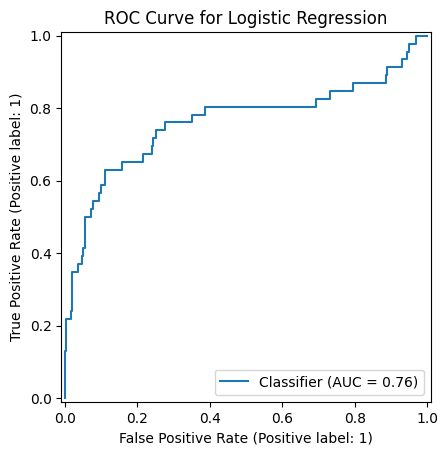

threshold=0.2: precision=0.433, recall=0.630, FP=38, FN=17
threshold=0.5: precision=0.762, recall=0.348, FP=5, FN=30
threshold=0.8: precision=1.000, recall=0.043, FP=0, FN=44


In [3]:
RocCurveDisplay.from_predictions(y_test, proba)
plt.title('ROC Curve for Logistic Regression')
plt.show()

for threshold in [0.2, 0.5, 0.8]:
    custom_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, custom_pred).ravel()
    precision = tp/(tp+fp) if tp+fp else 0
    recall = tp/(tp+fn) if tp+fn else 0
    print(f'threshold={threshold}: precision={precision:.3f}, recall={recall:.3f}, FP={fp}, FN={fn}')

### Output Interpretation

Lowering the threshold usually increases recall but also increases false positives. The best threshold depends on business or operational cost.

## 3. Naive Bayes Comparison

In [4]:
nb = GaussianNB().fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_proba = nb.predict_proba(X_test)[:,1]
print('Naive Bayes report:')
print(classification_report(y_test, nb_pred, zero_division=0))
print('Naive Bayes ROC-AUC:', round(roc_auc_score(y_test, nb_proba), 4))

Naive Bayes report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       254
           1       0.83      0.41      0.55        46

    accuracy                           0.90       300
   macro avg       0.86      0.70      0.75       300
weighted avg       0.89      0.90      0.88       300

Naive Bayes ROC-AUC: 0.8023


### Output Interpretation

Naive Bayes can be effective and fast, but its independence assumption can limit performance when predictors are strongly related.

## Extended Study Notes

The most important professional habit in practical statistics is interpretation. A statistic is not useful only because it can be computed; it is useful when it answers a real question about data quality, uncertainty, relationships, prediction, or decision-making. In data science work, the same numerical result can have different meanings depending on the sampling process, the metric used, the business cost of errors, and the assumptions behind the procedure.

This notebook intentionally uses original, simplified examples instead of copying the book examples verbatim. The purpose is academic understanding: connect the statistical concept to a runnable Python workflow, inspect the output, and explain what the output means. This also supports academic integrity because the notebook demonstrates the learned concept in original wording and with adapted code.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, Python implementation, output interpretation, and practical data science context.

## Key Takeaways

- Statistical concepts should be connected to data science decisions, not treated as isolated formulas.
- Visual summaries and resampling methods often provide practical intuition beyond formula-based statistics.
- Model evaluation must consider uncertainty, bias, sampling, and the cost of incorrect conclusions.
- The output of code should always be interpreted in context before making decisions.